# Data Features Selection
This notebook is the base for features  selection
## Used libraries

In [3]:
# type: ignore
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from time import time
import shap
import tables 

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE, SelectKBest, SelectFromModel, f_classif, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import cross_val_score 
from sklearn.isotonic import spearmanr
from sklearn.model_selection import KFold
from sklearn.base import clone


from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.multitest import multipletests


C:\Users\Hassan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data
- Cleaning infinite values and NaNs after the previous feature augmentation
- Looking for potential highly correlated features

In [4]:
train = pd.read_parquet('../train_extended.parquet')
test = pd.read_parquet('../test_extended.parquet')

## Feature selection
Several approch were used here :
- Trees Feature Importance
- RFE
- Statistical test
- Dimension reduction
- SFS

In [5]:
x_train, y_train = train.drop('RET', axis=1), train['RET']

In [6]:
ret_cols = ['RET_%d' % i for i in range(1, 6)]
volume_cols = ['VOLUME_%d' % i for i in range(1, 6)]
cat_cols = ['DATE','STOCK','INDUSTRY','INDUSTRY_GROUP','SECTOR','SUB_INDUSTRY']
# using regex to filter temporal and sectorial aggregation features
DATE_cols = x_train.filter(regex='\w+_\d+_DATE_\w+').columns.tolist()
SECTOR_cols = x_train.filter(regex='\w+_\d+_SECTOR_DATE_\w+').columns.tolist()
INDUSTRY_GROUP_cols = x_train.filter(regex='\w+_\d+_INDUSTRY_GROUP_DATE_\w+').columns.tolist()
INDUSTRY_cols = x_train.filter(regex='\w+_\d+_INDUSTRY_DATE_\w+').columns.tolist()
SUB_INDUSTRY_cols = x_train.filter(regex='\w+_\d+_SUB_INDUSTRY_DATE_\w+').columns.tolist()
# other patterns to filter the others features
ROLLING_STATS_cols = x_train.columns[x_train.columns.str.endswith('D')].tolist()
WEEK_cols = x_train.columns[x_train.columns.str.contains('WEEK')].tolist()
INDICATOR_cols = x_train.columns[x_train.columns.str.endswith('VOLUME') | x_train.columns.str.endswith('RET') | x_train.columns.str.contains('RSI') | x_train.columns.str.contains('ADL')].tolist()
VOLATILITY_cols = x_train.columns[x_train.columns.str.contains('VOLATILITY')].tolist()

In [ ]:
features = list(set(ret_cols+volume_cols+DATE_cols+SECTOR_cols+ROLLING_STATS_cols+WEEK_cols+INDICATOR_cols+VOLATILITY_cols))
len(features)

### Statistical analysis
- Correlations 
- Mutual information
- Information coefficient
- Feature importance
- SHAP Values

#### Correlations

In [ ]:
def correlation_features(train, features):
    X = train[features]
    corr_common = X.corr(method='spearman')
    mask = np.triu(np.ones_like(corr_common, dtype=bool))
    fig, ax = plt.subplots(figsize=(22, 18))
    cmap = sns.diverging_palette(10, 220, as_cmap=True)

    heatmap = sns.heatmap(corr_common, mask=mask, cmap=cmap, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})

    fig.tight_layout()
    clustermap = sns.clustermap(corr_common, cmap=cmap, figsize=(15, 15))
    corr_ = corr_common.stack().reset_index()
    corr_.columns = ['x1', 'x2', 'rho']
    corr_ = corr_[corr_.x1!=corr_.x2].drop_duplicates('rho')

    corr_.sort_values('rho', ascending=False)

    return corr_, clustermap, heatmap

In [ ]:
def correlation_target(train, features):
    X = train[features]
    y = train['RET']
    corr_target = X.corrwith(y, method='spearman')
    corr_target = corr_target.sort_values(ascending=False)
    return corr_target

In [ ]:
fwd_corr = correlation_target(train, features)
top50 = fwd_corr.abs().nlargest(50).index
fwd_corr.loc[top50].sort_values().plot.barh(figsize=(10, 15), legend=False)

#### Mutual Information

In [ ]:
mi = {}
for feature in tqdm(features):
    df = (train.loc[:, ['RET', feature]].dropna().sample(n=100000))
    discrete_features = df[feature].nunique() < 10
    mi[feature] = mutual_info_classif(X=df[[feature]],y=df.RET,discrete_features=discrete_features)[0]
mi = pd.Series(mi)
mi.nlargest(50).sort_values().plot.barh(figsize=(8, 14))

#### RandomForest Feature Importance

In [ ]:
def feature_importance(model, features, x_train, y_train):
    X = x_train[features]
    y = y_train
    model.fit(X, y)
    fi = pd.DataFrame(model.feature_importances_, index=features, columns=['importance']).sort_values('importance', ascending=False)
    sns.barplot(x=fi, y=X.columns, orient='h')
    return pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

In [ ]:
fi = feature_importance(RandomForestClassifier(n_estimators=500, max_depth=6, n_jobs=-1, verbose=1), features, x_train, y_train)

#### SHAP values

In [ ]:
def shap_values(model, features, x_train, y_train):
    shap.initjs()
    X = x_train[features]
    y = y_train
    model.fit(X, y)
    print('Model trained')
    explainer = shap.TreeExplainer(model)
    print('Explainer created')
    shap_values = explainer.shap_values(X, y, approximate=True, check_additivity=False)
    print('SHAP values calculated')
    shap.summary_plot(shap_values, X)
    plt.gcf().suptitle('SHAP Values')
    plt.gcf().tight_layout()
    return shap_values

In [ ]:
shap_values = shap_values(RandomForestClassifier(n_estimators=10, n_jobs=-1, verbose=1), features, x_train, y_train)

#### Summary

In [ ]:
# reading all the statistics in h5 file 'features_statistics.h5'
mi = pd.read_hdf('features_statistics.h5', key='mi')
fi = pd.read_hdf('features_statistics.h5', key='fi')
fi = pd.Series(fi['importance'].values, index=fi.index)
fwd_corr = pd.read_hdf('features_statistics.h5', key='fwd_corr')

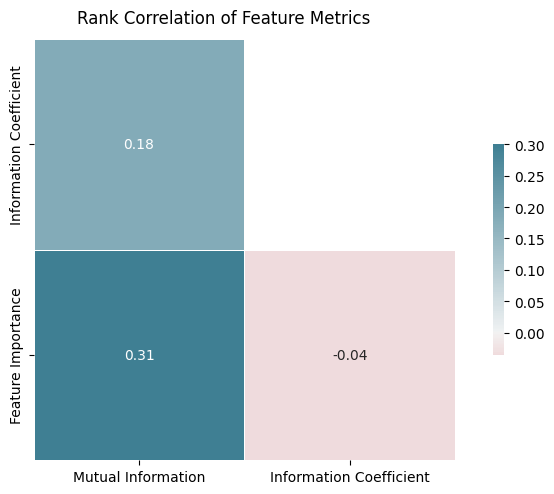

In [10]:

stats = (mi.to_frame('Mutual Information')
         .join(fwd_corr.to_frame('Information Coefficient'))
         .join(fi.to_frame('Feature Importance')))

cols = {'Information Coefficient': stats['Information Coefficient'].abs()}
corr = stats.assign(**cols).corr('spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
corr = corr.iloc[1:, :-1]
mask = mask[1:, :-1]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt='.2f')
plt.xticks(rotation=0)
fig.suptitle('Rank Correlation of Feature Metrics', fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=.92)


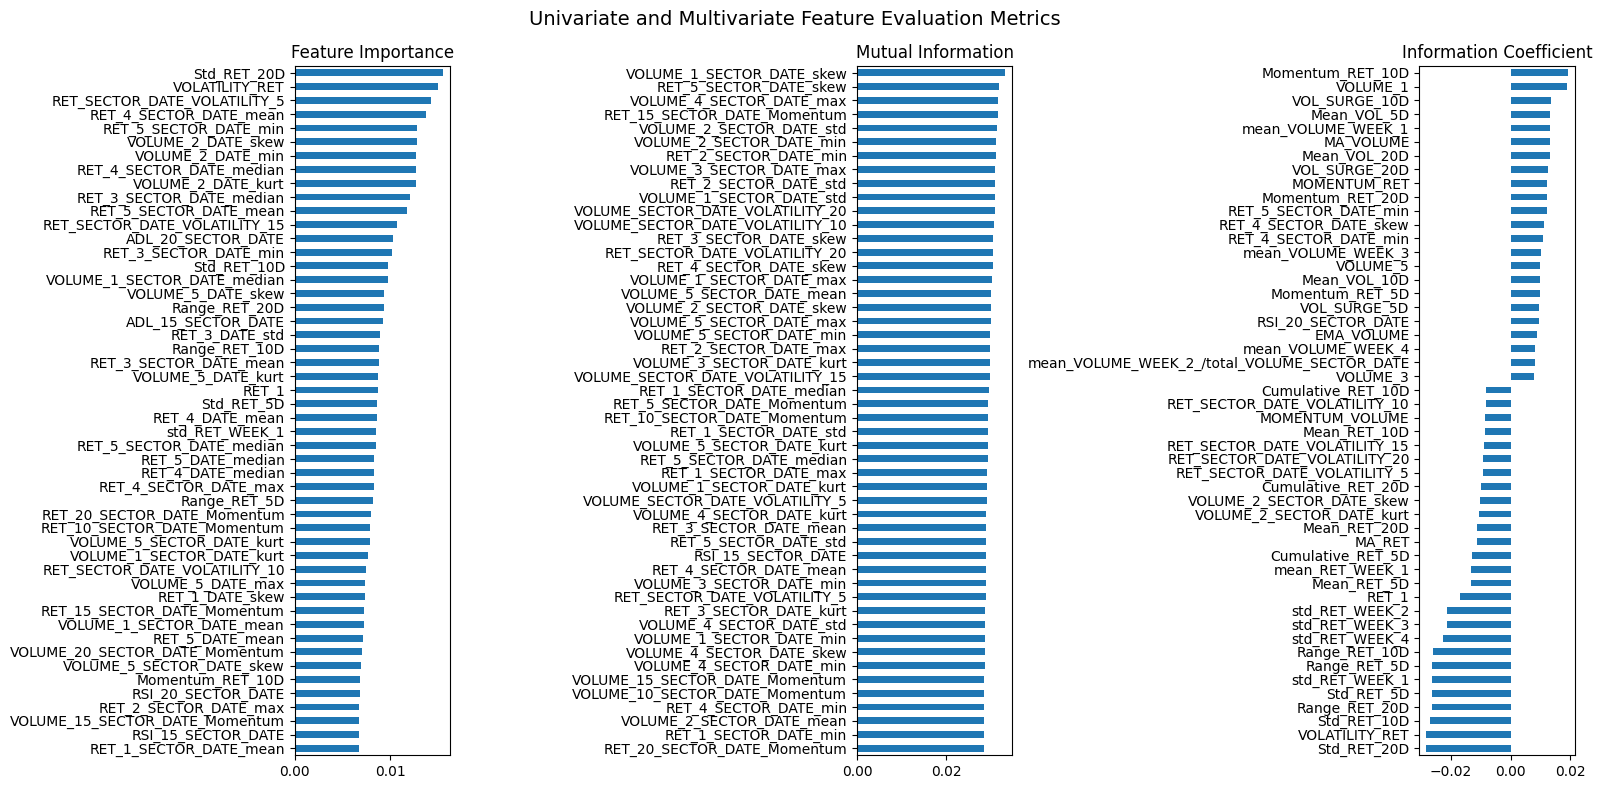

In [11]:
top_n = 50
fig, axes = plt.subplots(ncols=3, figsize=(16, 8))

fi.nlargest(top_n).sort_values().plot.barh(ax=axes[0], title='Feature Importance')
mi.nlargest(top_n).sort_values().plot.barh(ax=axes[1], title='Mutual Information')

top_corr = fwd_corr.abs().nlargest(top_n).index
fwd_corr.loc[top_corr].sort_values().plot.barh(ax=axes[2], title='Information Coefficient')

fig.suptitle('Univariate and Multivariate Feature Evaluation Metrics', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.91)

In [ ]:
# Cross-validation score for each type of feature selection

def cross_val_score_features(features, x_train, y_train, top_n = 50):
    selectedFeatures = features.abs().nlargest(top_n).index
    X = x_train[selectedFeatures]
    y = y_train
    model = RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1, verbose=1)
    scores = cross_val_score(model, X, y, cv=4, scoring='accuracy', verbose=1)
    return scores

mi_scores = cross_val_score_features(mi, x_train, y_train)
fi_scores = cross_val_score_features(fi, x_train, y_train)
fwd_corr_scores = cross_val_score_features(fwd_corr, x_train, y_train)

In [ ]:
top_fi = 35
top_mi = 256
top_fwd_corr = 256
selectedFeatures = list(set(fi.abs().nlargest(top_fi).index).intersection(set(fwd_corr.abs().nlargest(top_fwd_corr).index).union(mi.abs().nlargest(top_mi).index)))
selectedFeatures, len(selectedFeatures)

In [ ]:
selectedFeatures_scores = cross_val_score(RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1, verbose=1), 
                                          x_train[selectedFeatures], y_train, cv=4, scoring='accuracy', verbose=1)
selectedFeatures_scores

In [ ]:

scores = pd.DataFrame({'Feature Importance': fi_scores, 'Mutual Information': mi_scores, 'Information Coefficient': fwd_corr_scores, 'Selected Features': selectedFeatures_scores})
scores = scores.melt(var_name='Feature Selection', value_name='Accuracy')
sns.boxplot(x='Feature Selection', y='Accuracy', data=scores)
plt.title('Cross-validation score for each type of feature selection')
plt.show()



### Recursive Feature Elimination

In [ ]:
# Procedding to RFE forward selection from the selected features
# We will use the RandomForestClassifier as estimator
estimator = XGBClassifier(n_estimators=500, max_depth=8, n_jobs=-1)
selector = RFE(estimator, n_features_to_select=45, step=1, verbose=10)
selector.fit(x_train[pre_selectedFeatures], y_train)
selectedFeaturesXGB = pre_selectedFeatures[selector.support_]  # Get the selected features

In [ ]:
estimator2 = RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1)
selector2 = RFE(estimator2, n_features_to_select=45, step=1, verbose=10)
selector2.fit(x_train[pre_selectedFeatures], y_train)
selectedFeaturesRF = pre_selectedFeatures[selector2.support_]  # Get the selected features

In [ ]:
# save the selected features of the RFE XGB and RF by transforming them to a DataFrame then save them to a csv file
selectedFeaturesXGB = pd.DataFrame(selectedFeaturesXGB, columns=['feature'])
selectedFeaturesRF = pd.DataFrame(selectedFeaturesRF, columns=['feature'])
selectedFeaturesXGB.to_csv('selectedFeaturesXGB.csv')
selectedFeaturesRF.to_csv('selectedFeaturesRF.csv')

### Statistical significativity tests

In [ ]:
# Selection of features with SelectKBest f_classif
pipe_selection = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(score_func=f_classif, k='all'))
])

pipe_selection.fit(x_train, y_train)
scores = pipe_selection.named_steps['selector'].scores_

# put the scores in a DataFrame
scores_f = pd.DataFrame({'feature': x_train.columns, 'score': scores})
scores_f = scores_f.sort_values(by='score', ascending=False)
scores_f.to_csv('../scores_f.csv')

In [ ]:
# Selection of features with SelectKBest mutual_info_classif
pipe_selection = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(score_func=mutual_info_classif, k='all'))
])

pipe_selection.fit(x_train, y_train)
scores_mutual_info = pipe_selection.named_steps['selector'].scores_

# put the scores in a DataFrame
scores_mutual_info_f = pd.DataFrame({'feature': x_train.columns, 'score': scores_mutual_info})
scores_mutual_info_f = scores_mutual_info_f.sort_values(by='score', ascending=False)
scores_mutual_info_f.to_csv('../scores_mutual_info.csv')

In [ ]:

def feature_selection_classification(df, target_col, mi_threshold=0.01, pval_threshold=0.05, corr_threshold=0.9):
    """
    Selects the most relevant features for binary classification using:
    1. Mutual Information (MI) to detect nonlinear relationships.
    2. F-Test to compute p-values for statistical significance.
    3. False Discovery Rate (FDR) correction for multiple comparisons.
    4. Correlation filtering to remove redundant features.

    Parameters:
    - df (pd.DataFrame): Dataset containing features and target.
    - target_col (str): Name of the target variable (binary: 0 or 1).
    - mi_threshold (float): Minimum MI score for feature relevance.
    - pval_threshold (float): Maximum corrected p-value for feature selection.
    - corr_threshold (float): Maximum allowed correlation (default 0.9).

    Returns:
    - selected_features (list): List of chosen feature names.
    - df_selected (pd.DataFrame): New dataframe with selected features.
    """

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Compute Mutual Information for classification
    mi_scores = mutual_info_classif(X, y)
    mi_scores = pd.Series(mi_scores, index=X.columns)
    
    # Compute F-test p-values
    f_scores, p_values = f_classif(X, y)  
    p_values = pd.Series(p_values, index=X.columns)
    
    # Apply False Discovery Rate (FDR) correction for multiple comparisons
    _, p_values_corrected, _, _ = multipletests(p_values, alpha=pval_threshold, method='fdr_bh')
    p_values_corrected = pd.Series(p_values_corrected, index=X.columns)

    # Step 1: Select features based on MI and p-values
    # selected_features = mi_scores[(mi_scores > mi_threshold) & (p_values_corrected < pval_threshold)].index.tolist()

    # Step 2: Remove highly correlated features
    # df_selected = df[selected_features + [target_col]]  # Keep only selected features + target
    # corr_matrix = df_selected.corr().abs()

    # Identify highly correlated pairs
    # upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]

    # Final feature list after removing correlated features
    # selected_features = [f for f in selected_features if f not in to_drop]

    # Return final dataframe with selected features
    # return selected_features, df[selected_features + [target_col]]r
    return mi_scores, p_values, f_scores

mi_scores, p_values, f_scores = feature_selection_classification(train, 'RET')

### Dimension reduction through PCA

In [ ]:
# PCA Pipeline on the whole dataset

pipe_pca = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99))
])

pipe_pca.fit(x_train)

# draw the explained variance ratio of the PCA
plt.plot(pipe_pca.named_steps['pca'].explained_variance_ratio_)
plt.xlabel('Number of components')
plt.ylabel('Explained variance ratio')
plt.show()


In [ ]:
# train the model with the PCA selected features

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=45)),
    ('model', RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1))
])

scores = cross_val_score(pipe, x_train, y_train, cv=3, scoring='accuracy', verbose=10)
for i, score in enumerate(scores):
    print('Fold %d: %.3f' % (i, score))
print('Accuracy: %.3f +/- %.3f' % (scores.mean(), scores.std()))


### Sequential/Incremental Feature Selection (forward/backward)

In [60]:
start_features = pd.read_hdf('features_selection.h5', key='features_s').to_list()  # Features to keep
candidate_features = list( set(INDICATOR_cols) - set(start_features) )  # Candidate features
best_score = 0.5251  # Best score

start_features, len(start_features), candidate_features, len(candidate_features)

(['RET_1',
  'VOLUME_1',
  'RET_3_SECTOR_DATE_std',
  'Range_RET_10D',
  'RSI_15_SECTOR_DATE',
  'RET_1_DATE_skew',
  'VOLUME_5_DATE_max',
  'RET_1_SECTOR_DATE_median',
  'RET_5_DATE_median',
  'RET_SECTOR_DATE_VOLATILITY_15',
  'ADL_15_SECTOR_DATE',
  'RET_3_DATE_max',
  'VOLUME_1_DATE_median',
  'VOLATILITY_RET',
  'Std_RET_10D',
  'RSI_20_SECTOR_DATE',
  'RET_5_DATE_mean',
  'RET_1_SECTOR_DATE_mean',
  'Range_RET_20D',
  'RET_SECTOR_DATE_VOLATILITY_5',
  'RET_5_SECTOR_DATE_std',
  'VOLUME_2_DATE_min',
  'RET_SECTOR_DATE_VOLATILITY_20',
  'Momentum_RET_10D',
  'std_RET_WEEK_1',
  'VOLUME_5_SECTOR_DATE_skew',
  'RET_15_SECTOR_DATE_Momentum',
  'RET_3_DATE_mean',
  'VOLUME_SECTOR_DATE_VOLATILITY_15'],
 29,
 ['MOMENTUM_RET',
  'ADL_5_SECTOR_DATE',
  'ADL_20_SECTOR_DATE',
  'VW_RET',
  'EMA_VOLUME',
  'LIKELIHOOD_RET',
  'RSI_10_SECTOR_DATE',
  'RSI_5_SECTOR_DATE',
  'MA_RET',
  'EMA_RET',
  'VOLATILITY_VOLUME',
  'MOMENTUM_VOLUME',
  'ADL_10_SECTOR_DATE',
  'MA_VOLUME',
  'RSI_RET'],
 1

In [ ]:
def incremental_selection_features(model, train, keep_features, candidates_features, min_score = 0):
    """
    Stepwise feature selection using a given model.

    Parameters:
    - model: Classifier or regressor object.
    - train: Training dataset (pd.DataFrame).
    - keep_features: List of features to keep.
    - candidate_features: List of candidate features to test.

    Returns:
    - selected_features: List of selected features.
    - scores: List of cross-validation scores.
    """

    # Initialize variables
    selected_features = keep_features.copy()
    scores = []
    best_score = min_score

    y = train['RET']

    # Iterate over candidate features
    for feature in tqdm(candidates_features):
        # Add feature to selected features
        selected_features.append(feature)

        # Extract training data
        X = train[selected_features]
        
        # Compute cross-validation score
        score = cross_val_score(model, X, y, cv=3, scoring='accuracy').mean()
        scores.append(score)

        # Remove feature if score is not improved
        if score <= best_score:
            selected_features.remove(feature)
        else:
            best_score = score
            print(f'new best score: {best_score}')

    append_features = list(set(selected_features) - set(keep_features))

    return selected_features, append_features, max(scores)

In [41]:
features_s, features_a, score = incremental_selection_features(RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1), train, start_features, candidate_features, min_score=0.52493)

 64%|██████▎   | 14/22 [11:15<06:23, 47.94s/it]

new best score: 0.525101289855392


100%|██████████| 22/22 [25:52<00:00, 70.58s/it] 
